# Titanic Survival Prediction: Logistic Regression vs SVM

## 1. Load and explore the data

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
print('Shape:', df.shape, "\n")

print('Missing values:')
print(df.isnull().sum(), "\n")

print('Survival rate (class balance):')
print(df['Survived'].value_counts(normalize=True).round(3))

Shape: (891, 12) 

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 

Survival rate (class balance):
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


About 38% of passengers survived. The classes are not balanced. A model that always predicts "not survived" would get about 62% accuracy. So accuracy alone is not enough. Recall and the confusion matrix matter here.

## 2. Preprocessing

In [12]:
data = df.copy()

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['Embarked'], prefix='Embarked', dtype=int)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked_C', 'Embarked_Q', 'Embarked_S']
X = data[features]
y = data['Survived']

print('Features shape:', X.shape)
print('Label shape:', y.shape)

Features shape: (891, 9)
Label shape: (891,)


## 3. Train / test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 712
Test size:  179


## 4. Logistic Regression

In [14]:
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print('LR Accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))
print('LR Recall:  ', round(recall_score(y_test, y_pred_lr), 4))

LR Accuracy: 0.8045
LR Recall:   0.6667


In [15]:
coefs = pd.Series(lr_model.named_steps['logisticregression'].coef_[0], index=features)
print(coefs.sort_values().round(3))

Pclass       -0.928
Age          -0.502
SibSp        -0.262
Embarked_S   -0.115
Parch        -0.067
Embarked_C    0.052
Fare          0.099
Embarked_Q    0.114
Sex           1.270
dtype: float64


## 5. SVM

In [16]:
# SVM WITHOUT scaling (for comparison only)
svm_noscale = SVC(kernel='rbf', random_state=42)
svm_noscale.fit(X_train, y_train)
y_pred_noscale = svm_noscale.predict(X_test)

print('SVM (no scaling) Accuracy:', round(accuracy_score(y_test, y_pred_noscale), 4))
print('SVM (no scaling) Recall:  ', round(recall_score(y_test, y_pred_noscale), 4))

SVM (no scaling) Accuracy: 0.6201
SVM (no scaling) Recall:   0.2319


In [17]:
# SVM WITH scaling (the model used from here on)
svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
print('SVM (scaled) Accuracy:', round(accuracy_score(y_test, y_pred_svm), 4))
print('SVM (scaled) Recall:  ', round(recall_score(y_test, y_pred_svm), 4))

SVM (scaled) Accuracy: 0.8156
SVM (scaled) Recall:   0.6232


## 6. Hyperparameter tuning

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='accuracy'
)
lr_grid.fit(X_train, y_train)

svm_grid = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)),
    param_grid={'svc__C': [0.1, 1, 10, 100],
                'svc__gamma': ['scale', 0.001, 0.01, 0.1, 1]},
    cv=cv, scoring='accuracy'
)
svm_grid.fit(X_train, y_train)

print('LR  best params:', lr_grid.best_params_, '| CV accuracy:', round(lr_grid.best_score_, 4))
print('SVM best params:', svm_grid.best_params_, '| CV accuracy:', round(svm_grid.best_score_, 4))

lr_best = lr_grid.best_estimator_
svm_best = svm_grid.best_estimator_

LR  best params: {'logisticregression__C': 0.01} | CV accuracy: 0.809
SVM best params: {'svc__C': 1, 'svc__gamma': 0.1} | CV accuracy: 0.8216


## 7. Compare the two models on the test set

In [19]:
models = {
    'LR (default C)':        lr_model,
    'LR (tuned)':            lr_best,
    'SVM (no scaling)':      svm_noscale,
    'SVM (scaled)':          svm_model,
    'SVM (scaled + tuned)':  svm_best,
}

rows = []
for name, m in models.items():
    p = m.predict(X_test)
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, p),
        'Recall':    recall_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'F1':        f1_score(y_test, p),
    })

results = pd.DataFrame(rows).set_index('Model').round(4)
results

,Accuracy,Recall,Precision,F1
Model,,,,
LR (default C),0.8045,0.6667,0.7931,0.7244
LR (tuned),0.7989,0.5797,0.8511,0.6897
SVM (no scaling),0.6201,0.2319,0.5161,0.3200
SVM (scaled),0.8156,0.6232,0.8600,0.7227
SVM (scaled + tuned),0.8045,0.6087,0.8400,0.7059


Cross-validation on the full data gives a more stable comparison than one test split of 179 rows.

In [20]:
cv_rows = []
for name, m in [('LR (default C)', lr_model), ('SVM (scaled)', svm_model),
                ('SVM (no scaling)', SVC(kernel='rbf', random_state=42))]:
    scores = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
    cv_rows.append({'Model': name, 'Mean CV accuracy': scores.mean(), 'Std': scores.std()})

pd.DataFrame(cv_rows).set_index('Model').round(4)

,Mean CV accuracy,Std
Model,,
LR (default C),0.7924,0.0207
SVM (scaled),0.8271,0.0154
SVM (no scaling),0.6779,0.0153


### Confusion matrices

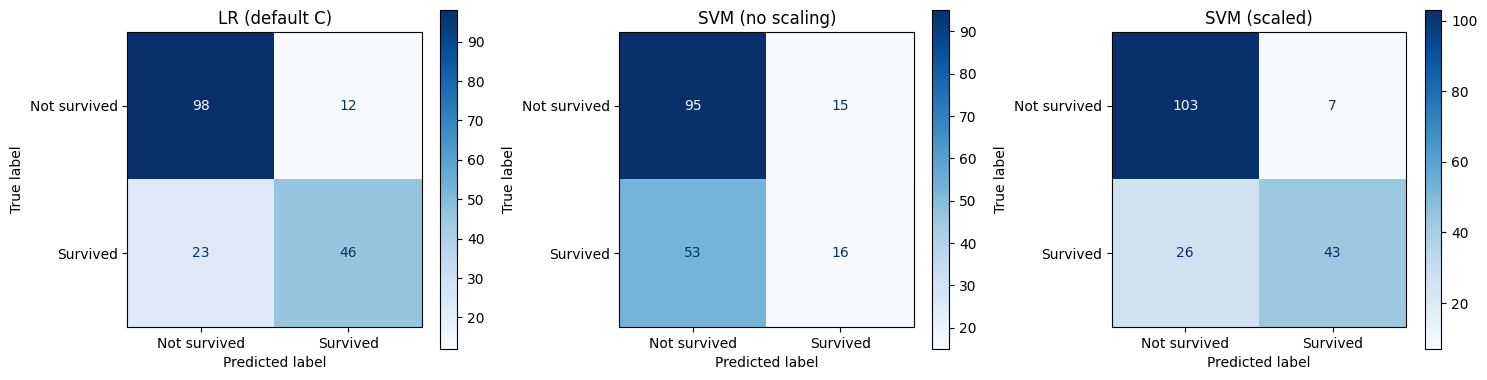

LR confusion matrix (rows = actual, cols = predicted):
[[98 12]
 [23 46]] 

SVM (scaled) confusion matrix (rows = actual, cols = predicted):
[[103   7]
 [ 26  43]]


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, m) in zip(axes, [('LR (default C)', lr_model),
                                ('SVM (no scaling)', svm_noscale),
                                ('SVM (scaled)', svm_model)]):
    cm = confusion_matrix(y_test, m.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Not survived', 'Survived']).plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

print('LR confusion matrix (rows = actual, cols = predicted):')
print(confusion_matrix(y_test, y_pred_lr), "\n")

print('SVM (scaled) confusion matrix (rows = actual, cols = predicted):')
print(confusion_matrix(y_test, y_pred_svm))

## 8. Predict on three new passengers

In [22]:
new_passengers = pd.DataFrame({
    'Pclass':     [1,   3,    2],
    'Sex':        [1,   0,    0],       # 1 = female, 0 = male
    'Age':        [28,  35,   22],
    'SibSp':      [1,   0,    1],
    'Parch':      [0,   0,    0],
    'Fare':       [100.0, 7.5, 20.0],
    'Embarked_C': [0,   0,    1],
    'Embarked_Q': [0,   0,    0],
    'Embarked_S': [1,   1,    0],
})[features]

label = {0: 'not survived', 1: 'survived'}
lr_pred  = lr_model.predict(new_passengers)
svm_pred = svm_model.predict(new_passengers)
lr_prob  = lr_model.predict_proba(new_passengers)[:, 1]

descriptions = ['1st class female, age 28', '3rd class male, age 35', '2nd class male, age 22']

for i in range(len(new_passengers)):
    print(f'Passenger {i + 1} ({descriptions[i]})')
    print(f'  Logistic Regression: {label[lr_pred[i]]} (survival probability {lr_prob[i]:.2f})')
    print(f'  SVM:                 {label[svm_pred[i]]}', "\n")

Passenger 1 (1st class female, age 28)
  Logistic Regression: survived (survival probability 0.92)
  SVM:                 survived 

Passenger 2 (3rd class male, age 35)
  Logistic Regression: not survived (survival probability 0.07)
  SVM:                 not survived 

Passenger 3 (2nd class male, age 22)
  Logistic Regression: not survived (survival probability 0.30)
  SVM:                 not survived 

